In [1]:
# Install required packages
install.packages(c(
  "readxl",
  "dplyr",
  "ggplot2",
  "cluster",
  "factoextra",
  "randomForest",
  "e1071",
  "caret",
  "pROC",
  "plotly",
  "tidyr"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘future’, ‘globals’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘diagram’, ‘lava’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘showtextdb’, ‘corrplot’, ‘prodlim’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘lazyeval’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘proxy’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘crosstalk’




In [2]:
# Load libraries

library(readxl)
library(dplyr)
library(ggplot2)
library(cluster)
library(factoextra)
library(randomForest)
library(e1071)
library(caret)
library(pROC)
library(plotly)
library(tidyr)

cat("All packages loaded successfully!\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following objec

All packages loaded successfully!


In [3]:
# Load Online Retail dataset

file_path <- "/content/Online Retail.xlsx"

retail <- read_excel(file_path)

# Display first 10 rows
head(retail, 10)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom


In [4]:
getwd()
list.files()

[1] "/content"

[1] "Online Retail.xlsx" "sample_data"

In [5]:
retail <- read_excel("Online Retail.xlsx")

In [6]:
# Number of rows and columns
dim(retail)

# Column names
colnames(retail)

# Structure
str(retail)

# Summary
summary(retail)

[1] 541909      8

[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


     InvoiceNo          StockCode         Description        Quantity         
 Length   :541909   Length   :541909   Length   :541909   Min.   :-80995.000  
 N.unique : 25900   N.unique :  4070   N.unique :  4211   1st Qu.:     1.000  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :     3.000  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     1   Mean   :     9.552  
 Max.nchar:     7   Max.nchar:    12   Max.nchar:    35   3rd Qu.:    10.000  
                                       NAs      :  1454   Max.   : 80995.000  
                                                                              
  InvoiceDate                    UnitPrice            CustomerID    
 Min.   :2010-12-01 08:26:00   Min.   :-11062.060   Min.   :12346   
 1st Qu.:2011-03-28 11:34:00   1st Qu.:     1.250   1st Qu.:13953   
 Median :2011-07-19 17:17:00   Median :     2.080   Median :15152   
 Mean   :2011-07-04 13:34:57   Mean   :     4.611   Mean   :15288   
 3rd Qu.:2011-10-19 11:

In [7]:
# Count missing values in every column

missing_values <- colSums(is.na(retail))

missing_values

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

In [8]:
missing_table <- data.frame(
  Column = names(missing_values),
  Missing = as.numeric(missing_values)
)

missing_table

Column,Missing
<chr>,<dbl>
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
# Number of duplicate rows

sum(duplicated(retail))

[1] 5268

In [10]:
retail <- retail %>%
  distinct()

cat("Rows after removing duplicates:", nrow(retail), "\n")

Rows after removing duplicates: 536641 


In [12]:
retail <- retail %>%
  filter(!is.na(CustomerID))

In [13]:
sum(is.na(retail$CustomerID))

[1] 0

In [14]:
# Number of cancelled invoices

sum(grepl("^C", retail$InvoiceNo))

[1] 8872

In [15]:
retail <- retail %>%
  filter(!grepl("^C", InvoiceNo))

In [16]:
retail <- retail %>%
  filter(Quantity > 0,
         UnitPrice > 0)

In [17]:
summary(retail$Quantity)
summary(retail$UnitPrice)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     2.00     6.00    13.12    12.00 80995.00 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.001    1.250    1.950    3.126    3.750 8142.750 

In [18]:
retail <- retail %>%
  mutate(
    TotalAmount = Quantity * UnitPrice
  )

In [19]:
head(retail[, c(
  "InvoiceNo",
  "Quantity",
  "UnitPrice",
  "TotalAmount",
  "CustomerID"
)])

InvoiceNo,Quantity,UnitPrice,TotalAmount,CustomerID
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
536365,6,2.55,15.30,17850
536365,6,3.39,20.34,17850
536365,8,2.75,22.00,17850
536365,6,3.39,20.34,17850
536365,6,3.39,20.34,17850
536365,2,7.65,15.30,17850


In [20]:
retail$InvoiceDate <- as.POSIXct(
  retail$InvoiceDate,
  format = "%Y-%m-%d %H:%M:%S"
)

str(retail$InvoiceDate)

 POSIXct[1:392692], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...


In [21]:
head(retail$InvoiceDate)

[1] "2010-12-01 08:26:00 UTC" "2010-12-01 08:26:00 UTC"
[3] "2010-12-01 08:26:00 UTC" "2010-12-01 08:26:00 UTC"
[5] "2010-12-01 08:26:00 UTC" "2010-12-01 08:26:00 UTC"

In [22]:
analysis_date <- max(retail$InvoiceDate) + 1

analysis_date

[1] "2011-12-09 12:50:01 UTC"

In [23]:
customer_data <- retail %>%
  group_by(CustomerID) %>%
  summarise(

    # Recency
    Recency = as.numeric(
      difftime(
        analysis_date,
        max(InvoiceDate),
        units = "days"
      )
    ),

    # Frequency = number of unique invoices
    Frequency = n_distinct(InvoiceNo),

    # Monetary Value
    Monetary = sum(TotalAmount),

    # Total quantity purchased
    TotalQuantity = sum(Quantity),

    # Average transaction value
    AvgTransactionValue = mean(TotalAmount),

    # Purchase frequency
    PurchaseFrequency = n_distinct(InvoiceNo)
  )

In [24]:
head(customer_data)

CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency
<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>
12346,325.117373,1,77183.60,74215,77183.60000,1
12347,1.873623,7,4310.00,2458,23.68132,7
12348,74.984039,4,1797.24,2341,57.97548,4
12349,18.124317,1,1757.55,631,24.07603,1
12350,309.867373,1,334.40,197,19.67059,1
12352,35.925706,8,2506.04,536,29.48282,8


In [25]:
dim(customer_data)

summary(customer_data)

[1] 4338    7

   CustomerID       Recency            Frequency          Monetary        
 Min.   :12346   Min.   :  0.00001   Min.   :  1.000   Min.   :     3.75  
 1st Qu.:13813   1st Qu.: 17.07241   1st Qu.:  1.000   1st Qu.:   306.48  
 Median :15300   Median : 50.08994   Median :  2.000   Median :   668.57  
 Mean   :15300   Mean   : 92.04933   Mean   :  4.272   Mean   :  2048.69  
 3rd Qu.:16779   3rd Qu.:141.73057   3rd Qu.:  5.000   3rd Qu.:  1660.60  
 Max.   :18287   Max.   :373.12293   Max.   :209.000   Max.   :280206.02  
 TotalQuantity      AvgTransactionValue PurchaseFrequency
 Min.   :     1.0   Min.   :    2.137   Min.   :  1.000  
 1st Qu.:   159.0   1st Qu.:   12.393   1st Qu.:  1.000  
 Median :   378.0   Median :   17.755   Median :  2.000  
 Mean   :  1187.6   Mean   :   68.382   Mean   :  4.272  
 3rd Qu.:   989.8   3rd Qu.:   24.879   3rd Qu.:  5.000  
 Max.   :196915.0   Max.   :77183.600   Max.   :209.000  

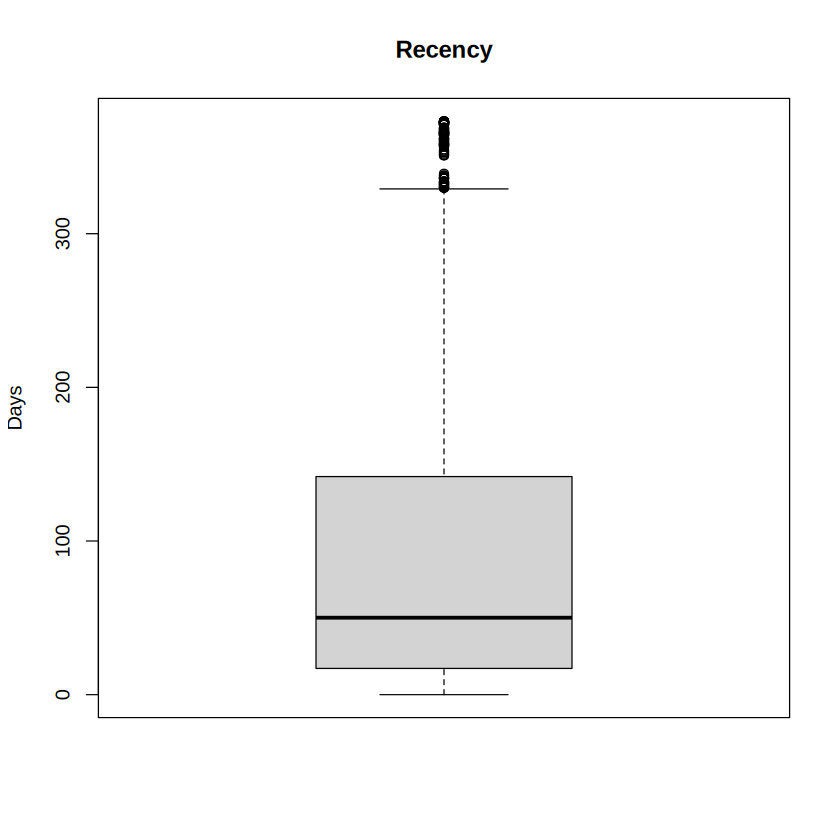

In [26]:
boxplot(
  customer_data$Recency,
  main = "Recency",
  ylab = "Days"
)

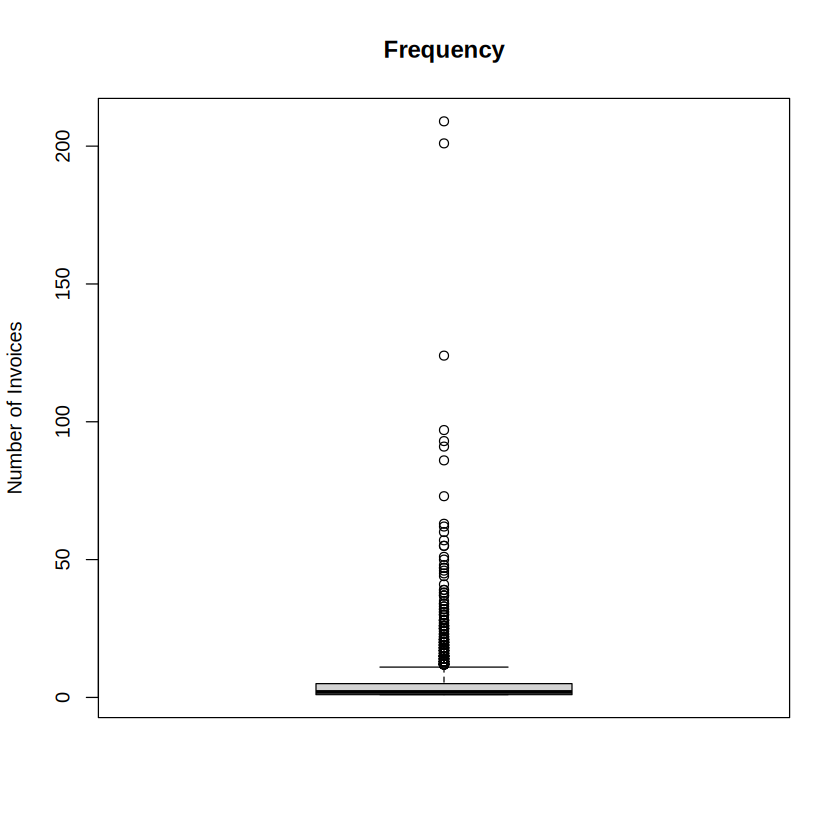

In [27]:
boxplot(
  customer_data$Frequency,
  main = "Frequency",
  ylab = "Number of Invoices"
)

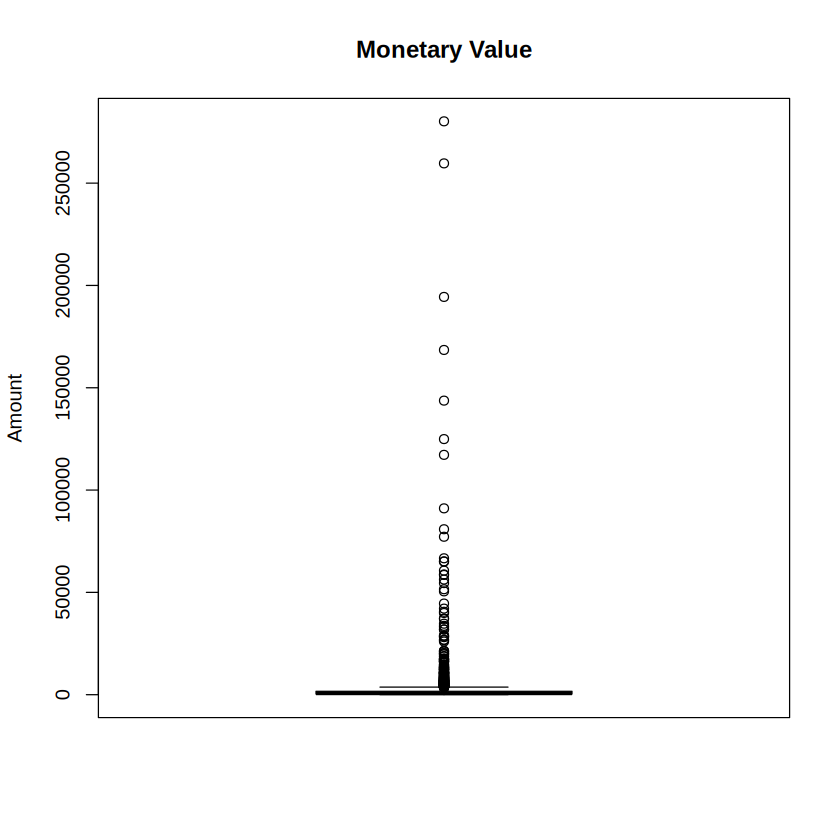

In [28]:
boxplot(
  customer_data$Monetary,
  main = "Monetary Value",
  ylab = "Amount"
)

In [29]:
remove_outliers <- function(x) {

  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)

  IQR_value <- Q3 - Q1

  lower <- Q1 - 1.5 * IQR_value
  upper <- Q3 + 1.5 * IQR_value

  x[x >= lower & x <= upper]
}

In [30]:
get_bounds <- function(x) {

  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)

  IQR_value <- Q3 - Q1

  c(
    lower = Q1 - 1.5 * IQR_value,
    upper = Q3 + 1.5 * IQR_value
  )
}

In [31]:
recency_bounds <- get_bounds(customer_data$Recency)
frequency_bounds <- get_bounds(customer_data$Frequency)
monetary_bounds <- get_bounds(customer_data$Monetary)
quantity_bounds <- get_bounds(customer_data$TotalQuantity)

In [32]:
customer_data_clean <- customer_data %>%
  filter(
    Recency >= recency_bounds["lower"],
    Recency <= recency_bounds["upper"],

    Frequency >= frequency_bounds["lower"],
    Frequency <= frequency_bounds["upper"],

    Monetary >= monetary_bounds["lower"],
    Monetary <= monetary_bounds["upper"],

    TotalQuantity >= quantity_bounds["lower"],
    TotalQuantity <= quantity_bounds["upper"]
  )

In [33]:
dim(customer_data)
dim(customer_data_clean)

[1] 4338    7

[1] 0 7

In [34]:
clustering_data <- customer_data_clean %>%
  select(
    Recency,
    Frequency,
    Monetary,
    TotalQuantity,
    AvgTransactionValue,
    PurchaseFrequency
  )

In [35]:
scaled_data <- scale(clustering_data)

head(scaled_data)

Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,PurchaseFrequency


In [36]:
summary(scaled_data)

    Recency      Frequency      Monetary   TotalQuantity AvgTransactionValue
 Min.   : NA   Min.   : NA   Min.   : NA   Min.   : NA   Min.   : NA        
 1st Qu.: NA   1st Qu.: NA   1st Qu.: NA   1st Qu.: NA   1st Qu.: NA        
 Median : NA   Median : NA   Median : NA   Median : NA   Median : NA        
 Mean   :NaN   Mean   :NaN   Mean   :NaN   Mean   :NaN   Mean   :NaN        
 3rd Qu.: NA   3rd Qu.: NA   3rd Qu.: NA   3rd Qu.: NA   3rd Qu.: NA        
 Max.   : NA   Max.   : NA   Max.   : NA   Max.   : NA   Max.   : NA        
 PurchaseFrequency
 Min.   : NA      
 1st Qu.: NA      
 Median : NA      
 Mean   :NaN      
 3rd Qu.: NA      
 Max.   : NA      

In [39]:
nrow(scaled_data)

[1] 0

In [40]:
nrow(unique(scaled_data))

[1] 0

In [41]:
dim(customer_data)
dim(customer_data_clean)

[1] 4338    7

[1] 0 7

In [42]:
customer_data_clean <- customer_data

In [43]:
nrow(customer_data_clean)

[1] 4338

In [44]:
cap_outliers <- function(x) {

  Q1 <- quantile(x, 0.25, na.rm = TRUE)
  Q3 <- quantile(x, 0.75, na.rm = TRUE)

  IQR_value <- Q3 - Q1

  lower <- Q1 - 1.5 * IQR_value
  upper <- Q3 + 1.5 * IQR_value

  x[x < lower] <- lower
  x[x > upper] <- upper

  return(x)
}

In [45]:
customer_data_clean$Recency <- cap_outliers(
  customer_data_clean$Recency
)

customer_data_clean$Frequency <- cap_outliers(
  customer_data_clean$Frequency
)

customer_data_clean$Monetary <- cap_outliers(
  customer_data_clean$Monetary
)

customer_data_clean$TotalQuantity <- cap_outliers(
  customer_data_clean$TotalQuantity
)

customer_data_clean$AvgTransactionValue <- cap_outliers(
  customer_data_clean$AvgTransactionValue
)

customer_data_clean$PurchaseFrequency <- cap_outliers(
  customer_data_clean$PurchaseFrequency
)

In [46]:
nrow(customer_data_clean)

[1] 4338

In [47]:
clustering_data <- customer_data_clean %>%
  select(
    Recency,
    Frequency,
    Monetary,
    TotalQuantity,
    AvgTransactionValue,
    PurchaseFrequency
  )

In [48]:
scaled_data <- scale(clustering_data)

In [49]:
dim(scaled_data)

[1] 4338    6

In [50]:
nrow(unique(scaled_data))

[1] 4338

In [51]:
set.seed(123)

wss <- numeric(10)

for (k in 1:10) {

  km <- kmeans(
    scaled_data,
    centers = k,
    nstart = 25
  )

  wss[k] <- km$tot.withinss
}

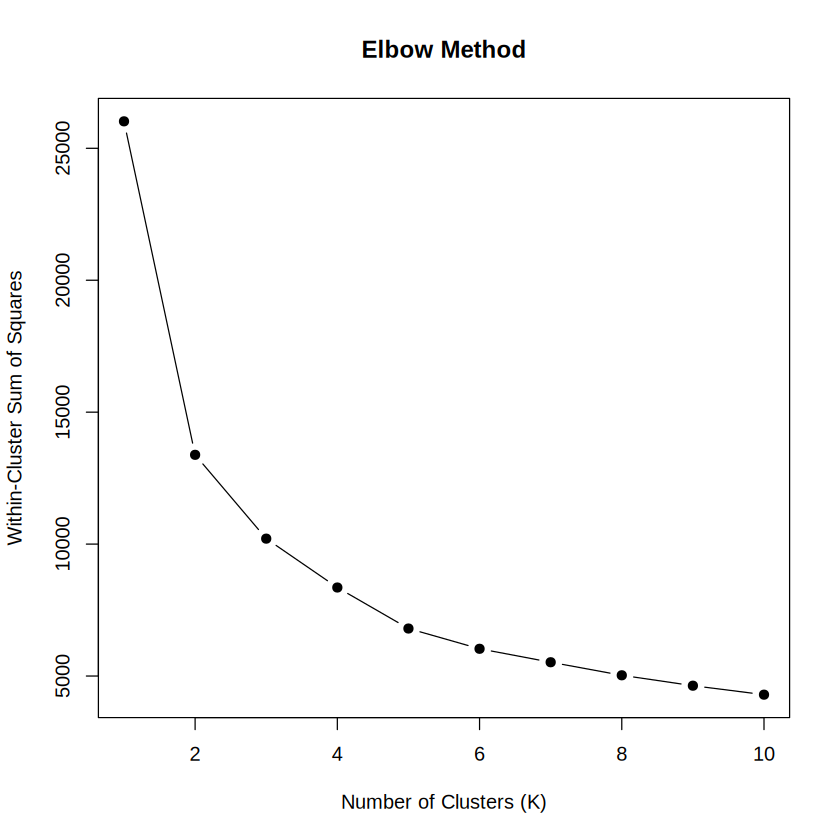

In [52]:
plot(
  1:10,
  wss,
  type = "b",
  pch = 19,
  xlab = "Number of Clusters (K)",
  ylab = "Within-Cluster Sum of Squares",
  main = "Elbow Method"
)

In [53]:
set.seed(123)

optimal_k <- 4

kmeans_model <- kmeans(
  scaled_data,
  centers = optimal_k,
  nstart = 25
)

kmeans_model

K-means clustering with 4 clusters of sizes 1849, 1007, 585, 897

Cluster means:
     Recency  Frequency   Monetary TotalQuantity AvgTransactionValue
1 -0.4101219 -0.4802882 -0.5546120    -0.5305869          -0.2972332
2  1.5955195 -0.6836880 -0.6687647    -0.6806111           0.1012058
3 -0.7297135  2.0817518  1.8853941     1.8192589           0.3237499
4 -0.4698889  0.3998906  0.6644014     0.6713089           0.2879334
  PurchaseFrequency
1        -0.4802882
2        -0.6836880
3         2.0817518
4         0.3998906

Clustering vector:
   [1] 4 3 4 1 2 4 2 2 2 4 4 1 4 4 2 3 1 4 2 1 4 4 4 2 1 1 2 4 1 4 4 4 1 2 4 1 1
  [38] 4 4 3 4 4 4 2 2 1 2 4 4 4 4 2 1 1 2 3 3 1 1 1 1 4 4 1 2 1 3 4 1 3 4 3 1 4
  [75] 1 3 4 2 1 4 1 1 2 1 4 2 4 1 1 4 4 4 4 1 1 1 4 4 1 2 3 3 4 3 1 3 3 1 1 4 3
 [112] 3 3 1 2 3 1 1 2 4 4 1 3 2 4 1 2 4 1 2 2 1 1 2 2 4 4 4 1 4 1 1 3 3 1 1 4 4
 [149] 1 1 1 1 4 1 4 3 1 1 1 1 2 2 1 2 1 3 1 4 1 2 4 2 3 2 2 1 3 3 1 1 2 2 4 1 4
 [186] 1 2 1 2 3 4 2 1 1 1 1 4 2 1 1 3 1 4 3 4 3 

In [54]:
customer_data_clean$Cluster <- factor(
  kmeans_model$cluster
)

In [55]:
table(customer_data_clean$Cluster)


   1    2    3    4 
1849 1007  585  897 

In [56]:
silhouette_result <- silhouette(
  kmeans_model$cluster,
  dist(scaled_data)
)

summary(silhouette_result)

Silhouette of 4338 units in 4 clusters from silhouette.default(x = kmeans_model$cluster, dist = dist(scaled_data)) :
 Cluster sizes and average silhouette widths:
     1849      1007       585       897 
0.3895452 0.3408056 0.4073000 0.1392570 
Individual silhouette widths:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-0.1868  0.1888  0.3550  0.3289  0.4920  0.6068 

In [57]:
avg_silhouette <- mean(
  silhouette_result[, 3]
)

avg_silhouette

[1] 0.3288714

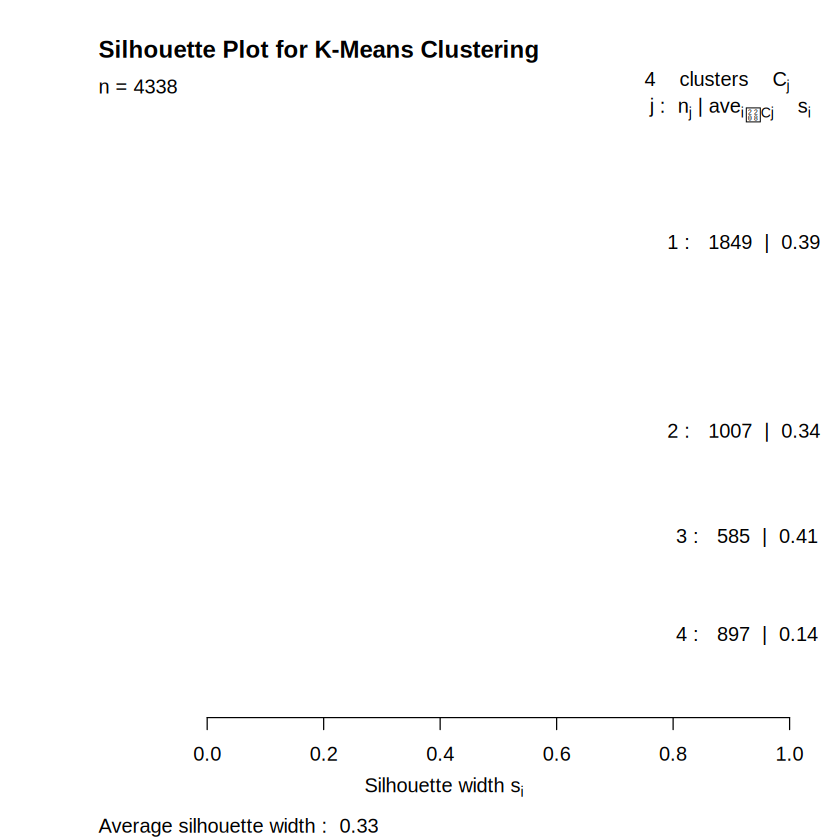

In [58]:
plot(
  silhouette_result,
  main = "Silhouette Plot for K-Means Clustering"
)


In [59]:
# Set seed for reproducibility
set.seed(123)

# Select a sample of customers
sample_size <- min(1000, nrow(scaled_data))

sample_index <- sample(
  1:nrow(scaled_data),
  sample_size
)

hierarchical_data <- scaled_data[sample_index, ]

dim(hierarchical_data)

[1] 1000    6

In [60]:
# Calculate Euclidean distance

distance_matrix <- dist(
  hierarchical_data,
  method = "euclidean"
)

head(distance_matrix)

,1,2,3,4,5,6,7,8,9,10,⋯,991,992,993,994,995,996,997,998,999,1000
1,0.000000,2.5735434,3.860042,2.2040281,1.9003790,2.5449013,2.2763165,1.5485183,4.335112,2.0689910,⋯,2.925425,2.4926462,0.9773796,0.6447046,1.288591,2.300693,2.930883,2.948511,2.5762102,2.4309304
2,2.573543,0.0000000,2.930770,0.9424809,0.8390337,0.6254169,0.3496060,1.3392946,4.192699,1.6148855,⋯,1.790563,1.6577522,3.2185923,2.6434137,2.559839,1.808677,1.780564,1.641625,0.9567673,0.6246014
3,3.860042,2.9307696,0.000000,2.8453078,2.9052060,2.9853738,3.0752742,3.1827314,4.176524,2.6582751,⋯,2.306058,2.5891941,4.6870431,4.0105560,4.378475,3.525687,3.452839,4.096915,2.7572359,2.6608498
4,2.204028,0.9424809,2.845308,0.0000000,0.8145119,0.7490243,0.8038592,0.7133899,3.419249,0.7307068,⋯,2.258474,0.9485343,2.7656057,2.0989292,2.029658,1.047712,1.082235,1.408062,0.3797630,1.2530002
5,1.900379,0.8390337,2.905206,0.8145119,0.0000000,1.1071693,0.6204136,0.8961383,3.799363,1.2576351,⋯,1.692495,1.6302243,2.6293603,1.9780818,2.106887,1.712058,1.781844,1.897723,1.0516398,0.7726647
6,2.544901,0.6254169,2.985374,0.7490243,1.1071693,0.0000000,0.6301985,1.1592731,4.090798,1.3802090,⋯,2.248713,1.2075344,3.0871397,2.5422988,2.321964,1.325304,1.489659,1.325224,0.7767387,1.1185214


In [61]:
# Hierarchical clustering using Ward's method

hc_model <- hclust(
  distance_matrix,
  method = "ward.D2"
)

hc_model


Call:
hclust(d = distance_matrix, method = "ward.D2")

Cluster method   : ward.D2 
Distance         : euclidean 
Number of objects: 1000 


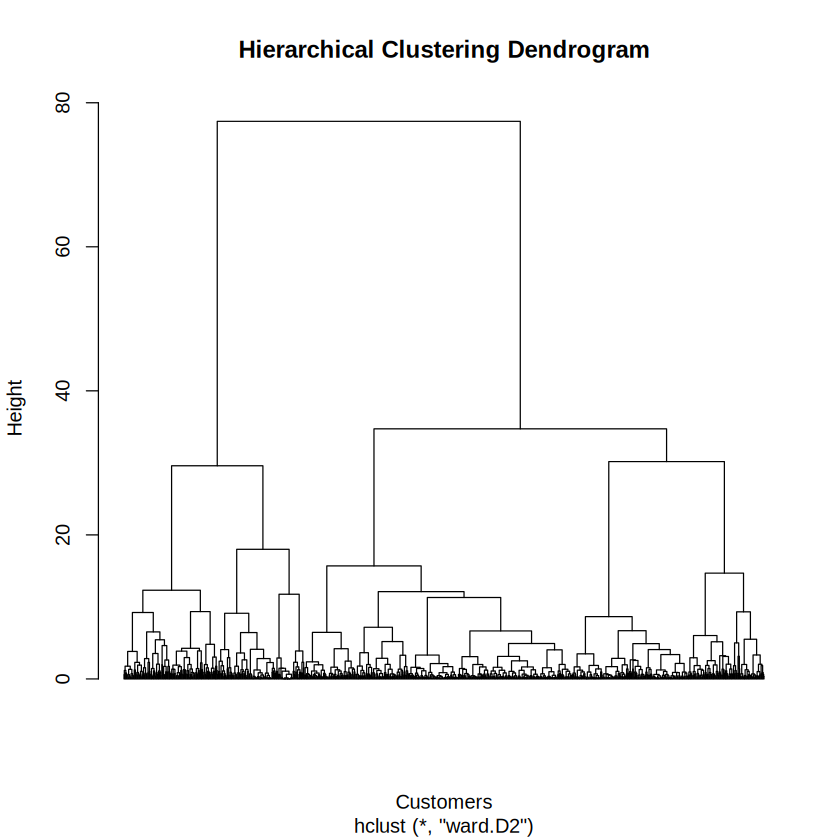

In [62]:
# Plot dendrogram

plot(
  hc_model,
  labels = FALSE,
  hang = -1,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "Customers",
  ylab = "Height"
)

In [63]:
optimal_k <- 4

In [64]:
# Create hierarchical clusters

hc_clusters <- cutree(
  hc_model,
  k = optimal_k
)

table(hc_clusters)

hc_clusters
  1   2   3   4 
181 418 119 282 

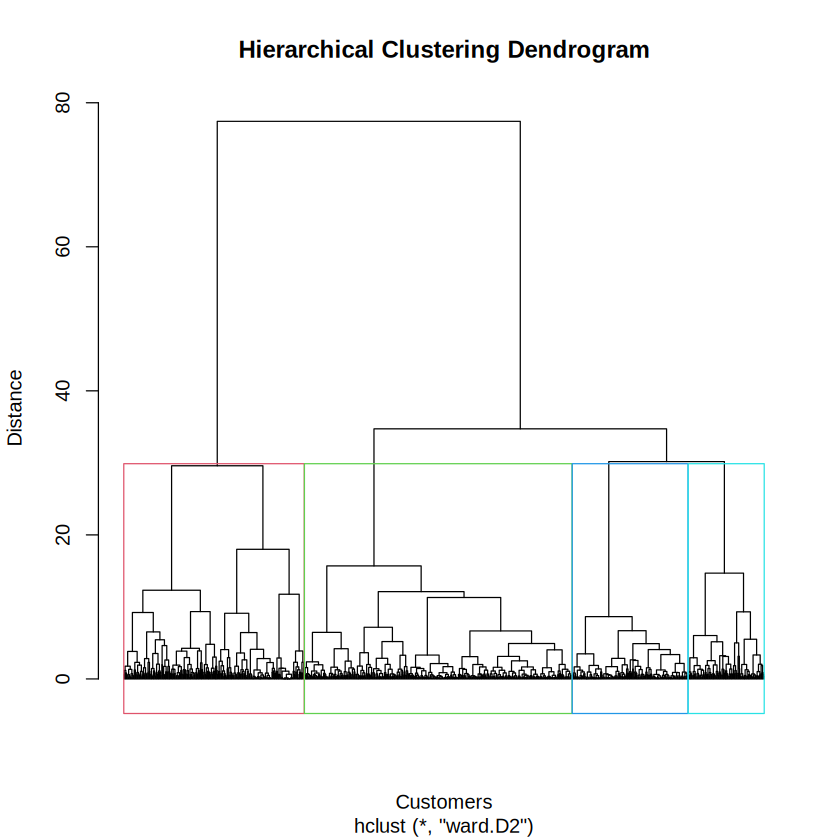

In [65]:
plot(
  hc_model,
  labels = FALSE,
  hang = -1,
  main = "Hierarchical Clustering Dendrogram",
  xlab = "Customers",
  ylab = "Distance"
)

rect.hclust(
  hc_model,
  k = optimal_k,
  border = 2:(optimal_k + 1)
)

In [66]:
# K-Means cluster labels for the same sampled customers

kmeans_sample_clusters <- customer_data_clean$Cluster[
  sample_index
]

# Create comparison table

cluster_comparison <- table(
  KMeans = kmeans_sample_clusters,
  Hierarchical = hc_clusters
)

cluster_comparison

      Hierarchical
KMeans   1   2   3   4
     1   3 366  47   2
     2 178  28  47   1
     3   0   0   0 139
     4   0  24  25 140

In [67]:
# Perform PCA

pca_model <- prcomp(
  scaled_data,
  center = TRUE,
  scale. = FALSE
)

summary(pca_model)

Importance of components:
                          PC1    PC2    PC3     PC4     PC5       PC6
Standard deviation     1.9648 1.0265 0.8295 0.58082 0.24572 1.116e-16
Proportion of Variance 0.6434 0.1756 0.1147 0.05623 0.01006 0.000e+00
Cumulative Proportion  0.6434 0.8190 0.9337 0.98994 1.00000 1.000e+00

In [68]:
# Calculate percentage of variance explained

variance_explained <- (
  pca_model$sdev^2 /
  sum(pca_model$sdev^2)
) * 100

variance_explained

[1] 6.434359e+01 1.756058e+01 1.146696e+01 5.622536e+00 1.006325e+00
[6] 2.075462e-31

In [69]:
pca_variance <- data.frame(
  Component = paste0(
    "PC",
    1:length(variance_explained)
  ),
  Variance_Percentage = variance_explained
)

pca_variance

Component,Variance_Percentage
<chr>,<dbl>
PC1,6.434359e+01
PC2,1.756058e+01
PC3,1.146696e+01
PC4,5.622536e+00
PC5,1.006325e+00
PC6,2.075462e-31


In [70]:
# Create dataframe containing PCA coordinates

pca_data <- data.frame(
  PC1 = pca_model$x[, 1],
  PC2 = pca_model$x[, 2],
  Cluster = customer_data_clean$Cluster
)

head(pca_data)

,PC1,PC2,Cluster
,<dbl>,<dbl>,<fct>
1,0.8304171,3.3766111,4
2,3.4987769,0.1960974,3
3,1.7186931,1.9783160,4
4,-0.3256276,0.2042236,1
5,-2.0963791,0.8456462,2
6,2.1347977,0.3933637,4


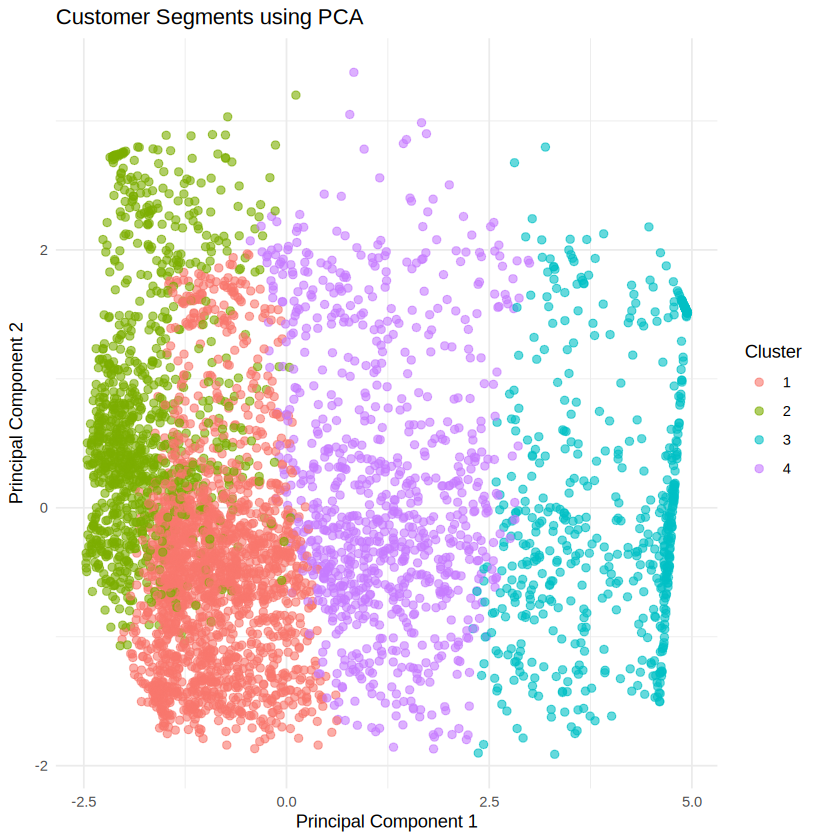

In [71]:
ggplot(
  pca_data,
  aes(
    x = PC1,
    y = PC2,
    color = Cluster
  )
) +
  geom_point(
    alpha = 0.6,
    size = 2
  ) +
  labs(
    title = "Customer Segments using PCA",
    x = "Principal Component 1",
    y = "Principal Component 2",
    color = "Cluster"
  ) +
  theme_minimal()

In [72]:
# PCA loadings

pca_loadings <- pca_model$rotation[, 1:2]

pca_loadings

,PC1,PC2
Recency,-0.2831452,0.39817760
Frequency,0.4814200,-0.08125192
Monetary,0.4780271,0.12975806
TotalQuantity,0.4665328,0.08283053
AvgTransactionValue,0.1006764,0.89696867
PurchaseFrequency,0.4814200,-0.08125192


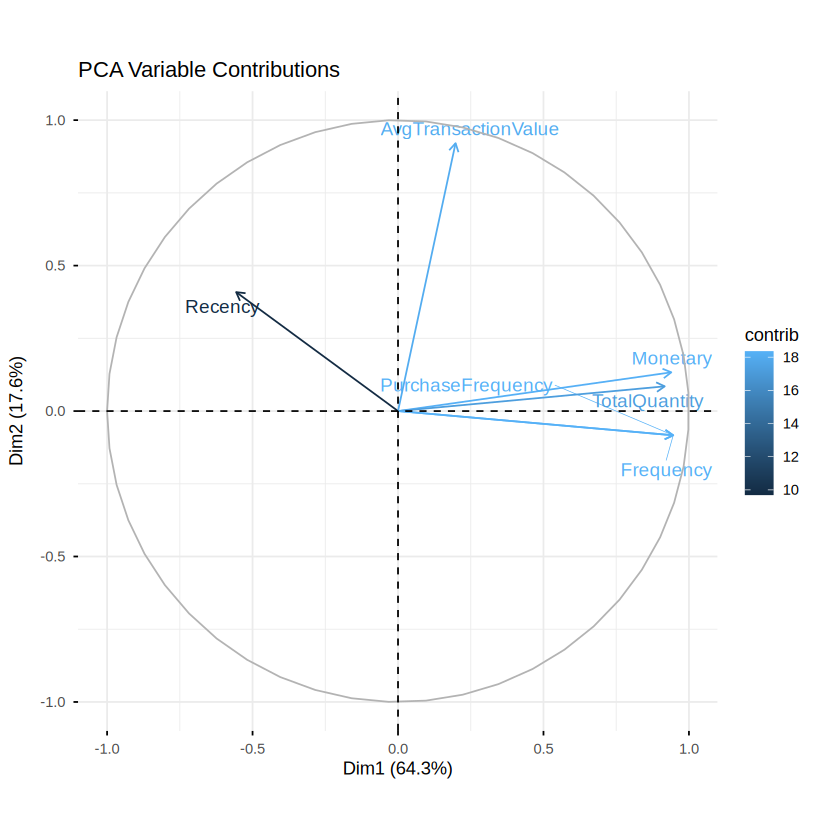

In [73]:
fviz_pca_var(
  pca_model,
  col.var = "contrib",
  repel = TRUE,
  title = "PCA Variable Contributions"
)

In [74]:
cluster_profile <- customer_data_clean %>%
  group_by(Cluster) %>%
  summarise(

    Customers = n(),

    Avg_Recency = mean(Recency),

    Avg_Frequency = mean(Frequency),

    Avg_Monetary = mean(Monetary),

    Avg_Quantity = mean(TotalQuantity),

    Avg_Transaction_Value = mean(
      AvgTransactionValue
    ),

    .groups = "drop"
  )

cluster_profile

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1849,51.09712,2.026501,522.9942,312.2217,16.62834
2,1007,246.25434,1.408143,392.0864,207.6334,21.26150
3,585,19.99953,9.815385,3321.1382,1950.4000,23.84930
4,897,45.28154,4.702341,1920.9314,1150.1148,23.43281


In [75]:
cluster_profile <- cluster_profile %>%
  mutate(
    across(
      where(is.numeric),
      ~ round(.x, 2)
    )
  )

cluster_profile

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1849,51.10,2.03,522.99,312.22,16.63
2,1007,246.25,1.41,392.09,207.63,21.26
3,585,20.00,9.82,3321.14,1950.40,23.85
4,897,45.28,4.70,1920.93,1150.11,23.43


In [76]:
cluster_profile %>%
  arrange(desc(Avg_Monetary))

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,585,20.00,9.82,3321.14,1950.40,23.85
4,897,45.28,4.70,1920.93,1150.11,23.43
1,1849,51.10,2.03,522.99,312.22,16.63
2,1007,246.25,1.41,392.09,207.63,21.26


In [77]:
high_value_cluster <- cluster_profile$Cluster[
  which.max(cluster_profile$Avg_Monetary)
]

high_value_cluster

[1] 3
Levels: 1 2 3 4

In [78]:
customer_data_clean$HighValue <- ifelse(
  customer_data_clean$Cluster == high_value_cluster,
  1,
  0
)

customer_data_clean$HighValue <- factor(
  customer_data_clean$HighValue,
  levels = c(0, 1),
  labels = c("No", "Yes")
)

table(customer_data_clean$HighValue)


  No  Yes 
3753  585 

In [79]:
table(customer_data_clean$HighValue)


  No  Yes 
3753  585 

In [80]:
prop.table(
  table(customer_data_clean$HighValue)
) * 100


      No      Yes 
86.51452 13.48548 

In [81]:
ml_data <- customer_data_clean %>%
  select(
    Recency,
    Frequency,
    Monetary,
    TotalQuantity,
    AvgTransactionValue,
    HighValue
  )

In [82]:
head(ml_data)

Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue,HighValue
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
325.117373,1,3691.77,2235.875,43.60758,No
1.873623,7,3691.77,2235.875,23.68132,Yes
74.984039,4,1797.24,2235.875,43.60758,No
18.124317,1,1757.55,631.000,24.07603,No
309.867373,1,334.40,197.000,19.67059,No
35.925706,8,2506.04,536.000,29.48282,No


In [83]:
set.seed(123)

train_index <- createDataPartition(
  ml_data$HighValue,
  p = 0.80,
  list = FALSE
)

train_data <- ml_data[train_index, ]

test_data <- ml_data[-train_index, ]

In [84]:
dim(train_data)
dim(test_data)

[1] 3471    6

[1] 867   6

In [85]:
table(train_data$HighValue)
table(test_data$HighValue)


  No  Yes 
3003  468 


 No Yes 
750 117 

In [86]:
set.seed(123)

rf_model <- randomForest(
  HighValue ~ .,
  data = train_data,
  ntree = 500,
  importance = TRUE
)

rf_model


Call:
 randomForest(formula = HighValue ~ ., data = train_data, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 0.37%
Confusion matrix:
      No Yes class.error
No  2997   6 0.001998002
Yes    7 461 0.014957265

In [87]:
rf_predictions <- predict(
  rf_model,
  newdata = test_data
)

head(rf_predictions)

1  2  3  4  5  6 
No No No No No No 
Levels: No Yes

In [88]:
rf_predictions <- predict(
  rf_model,
  newdata = test_data
)

head(rf_predictions)

1  2  3  4  5  6 
No No No No No No 
Levels: No Yes

In [89]:
rf_confusion <- confusionMatrix(
  rf_predictions,
  test_data$HighValue,
  positive = "Yes"
)

rf_confusion

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  746   2
       Yes   4 115
                                         
               Accuracy : 0.9931         
                 95% CI : (0.985, 0.9975)
    No Information Rate : 0.8651         
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.9706         
                                         
 Mcnemar's Test P-Value : 0.6831         
                                         
            Sensitivity : 0.9829         
            Specificity : 0.9947         
         Pos Pred Value : 0.9664         
         Neg Pred Value : 0.9973         
             Prevalence : 0.1349         
         Detection Rate : 0.1326         
   Detection Prevalence : 0.1373         
      Balanced Accuracy : 0.9888         
                                         
       'Positive' Class : Yes            
                                         

In [90]:
rf_accuracy <- rf_confusion$overall["Accuracy"]

rf_precision <- rf_confusion$byClass["Precision"]

rf_recall <- rf_confusion$byClass["Recall"]

rf_f1 <- rf_confusion$byClass["F1"]

rf_accuracy
rf_precision
rf_recall
rf_f1

Accuracy 
0.9930796

Precision 
0.9663866

Recall 
0.982906

F1 
0.9745763

In [91]:
rf_probability <- predict(
  rf_model,
  newdata = test_data,
  type = "prob"
)[, "Yes"]

In [92]:
rf_roc <- roc(
  test_data$HighValue,
  rf_probability,
  levels = c("No", "Yes"),
  direction = "<"
)

In [93]:
rf_auc <- auc(rf_roc)

rf_auc

Area under the curve: 0.9998

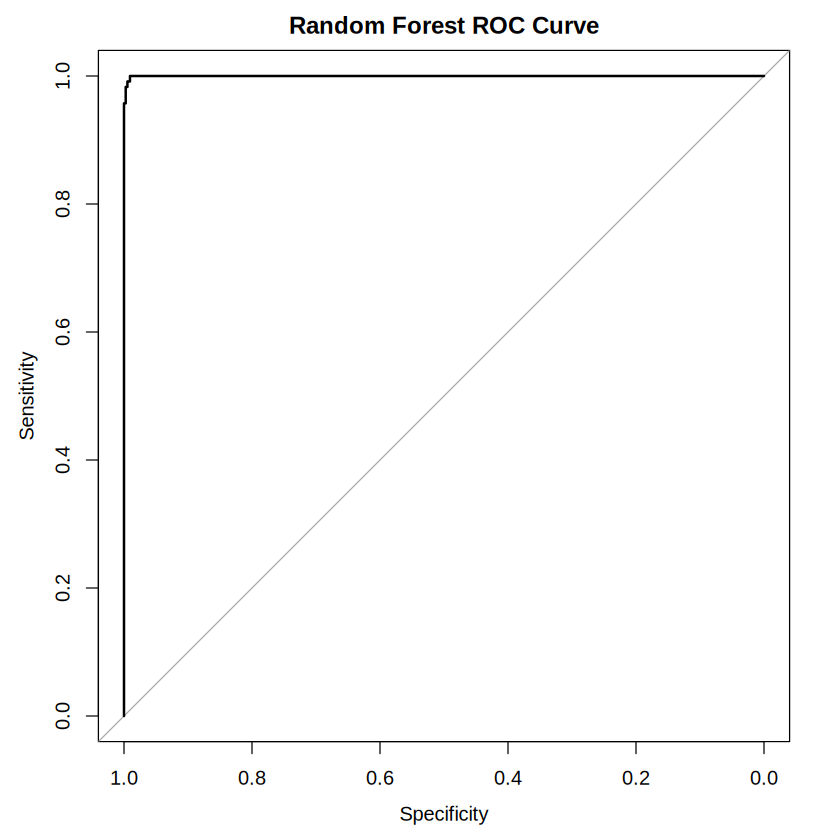

In [94]:
plot(
  rf_roc,
  main = "Random Forest ROC Curve"
)

In [95]:
importance(rf_model)

,No,Yes,MeanDecreaseAccuracy,MeanDecreaseGini
Recency,-3.118543,10.2056380,8.474427,32.63105
Frequency,53.543141,245.2680658,123.755042,433.27344
Monetary,8.986038,27.7102993,28.590676,192.22476
TotalQuantity,11.236036,31.3642739,35.680672,141.60909
AvgTransactionValue,7.763279,-0.6937425,5.603271,10.95571


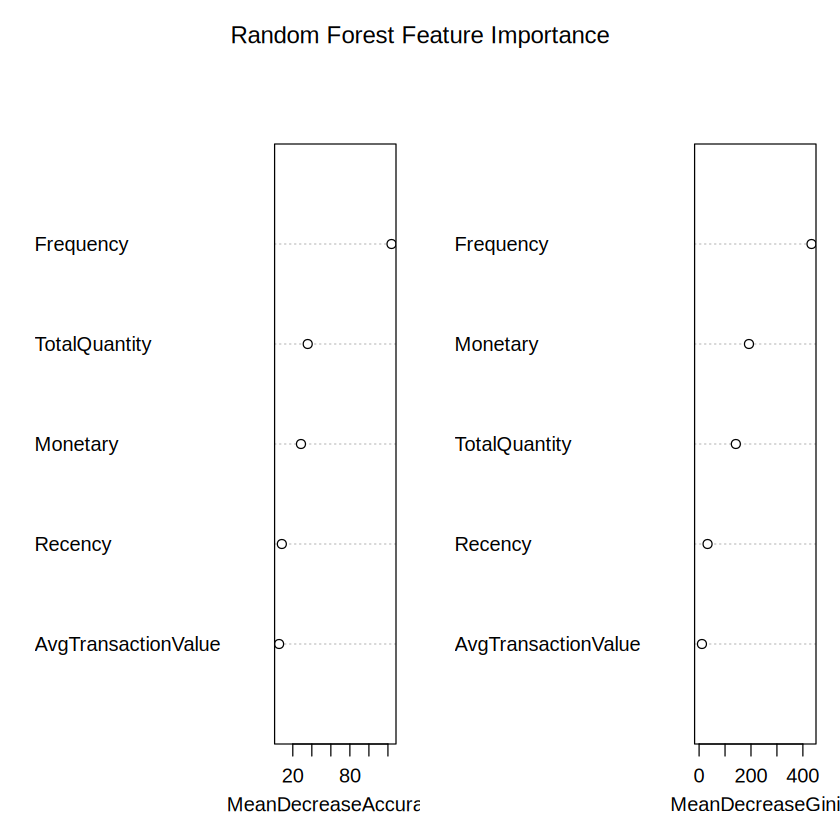

In [96]:
varImpPlot(
  rf_model,
  main = "Random Forest Feature Importance"
)

In [97]:
set.seed(123)

svm_model <- svm(
  HighValue ~ .,
  data = train_data,
  kernel = "radial",
  probability = TRUE
)

svm_model


Call:
svm(formula = HighValue ~ ., data = train_data, kernel = "radial", 
    probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  139


In [98]:
svm_predictions <- predict(
  svm_model,
  newdata = test_data
)

head(svm_predictions)

1  2  3  4  5  6 
No No No No No No 
Levels: No Yes

In [99]:
svm_confusion <- confusionMatrix(
  svm_predictions,
  test_data$HighValue,
  positive = "Yes"
)

svm_confusion

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  750   3
       Yes   0 114
                                          
               Accuracy : 0.9965          
                 95% CI : (0.9899, 0.9993)
    No Information Rate : 0.8651          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.985           
                                          
 Mcnemar's Test P-Value : 0.2482          
                                          
            Sensitivity : 0.9744          
            Specificity : 1.0000          
         Pos Pred Value : 1.0000          
         Neg Pred Value : 0.9960          
             Prevalence : 0.1349          
         Detection Rate : 0.1315          
   Detection Prevalence : 0.1315          
      Balanced Accuracy : 0.9872          
                                          
       'Positive' Class : Yes             
                              

In [100]:
svm_accuracy <- svm_confusion$overall["Accuracy"]

svm_precision <- svm_confusion$byClass["Precision"]

svm_recall <- svm_confusion$byClass["Recall"]

svm_f1 <- svm_confusion$byClass["F1"]

svm_accuracy
svm_precision
svm_recall
svm_f1

Accuracy 
0.9965398

Precision 
        1

Recall 
0.974359

F1 
0.987013

In [101]:
svm_probability <- attr(
  predict(
    svm_model,
    newdata = test_data,
    probability = TRUE
  ),
  "probabilities"
)[, "Yes"]

In [102]:
svm_roc <- roc(
  test_data$HighValue,
  svm_probability,
  levels = c("No", "Yes"),
  direction = "<"
)

In [103]:
svm_auc <- auc(svm_roc)

svm_auc

Area under the curve: 1

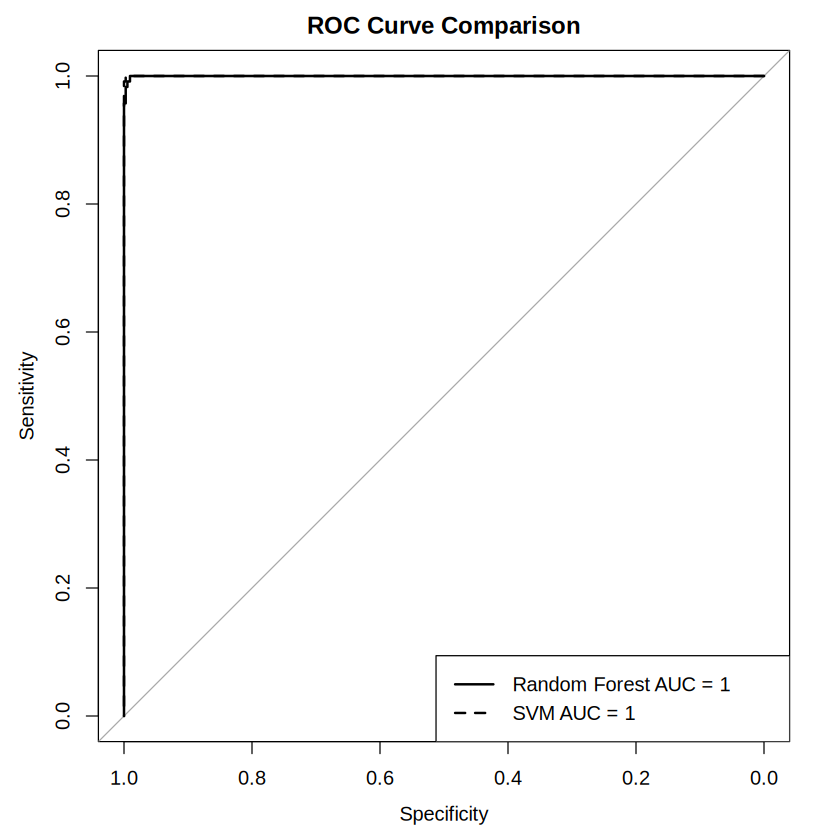

In [104]:
plot(
  rf_roc,
  main = "ROC Curve Comparison",
  lwd = 2
)

lines(
  svm_roc,
  lwd = 2,
  lty = 2
)

legend(
  "bottomright",
  legend = c(
    paste("Random Forest AUC =", round(rf_auc, 3)),
    paste("SVM AUC =", round(svm_auc, 3))
  ),
  lty = c(1, 2),
  lwd = 2
)

In [105]:
model_comparison <- data.frame(
  Model = c(
    "Random Forest",
    "SVM"
  ),

  Accuracy = c(
    as.numeric(rf_accuracy),
    as.numeric(svm_accuracy)
  ),

  Precision = c(
    as.numeric(rf_precision),
    as.numeric(svm_precision)
  ),

  Recall = c(
    as.numeric(rf_recall),
    as.numeric(svm_recall)
  ),

  F1_Score = c(
    as.numeric(rf_f1),
    as.numeric(svm_f1)
  ),

  ROC_AUC = c(
    as.numeric(rf_auc),
    as.numeric(svm_auc)
  )
)

model_comparison

Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Random Forest,0.9930796,0.9663866,0.982906,0.9745763,0.9998063
SVM,0.9965398,1.0000000,0.974359,0.9870130,0.9999772


In [106]:
pca_3d <- data.frame(
  PC1 = pca_model$x[, 1],
  PC2 = pca_model$x[, 2],
  PC3 = pca_model$x[, 3],
  Cluster = customer_data_clean$Cluster
)

In [109]:
plot_ly(
  pca_3d,
  x = ~PC1,
  y = ~PC2,
  z = ~PC3,
  color = ~Cluster,
  type = "scatter3d",
  mode = "markers",
  marker = list(
    size = 4
  )
) %>%
  layout(
    title = "3D PCA Visualization of Customer Segments",
    scene = list(
      xaxis = list(title = "PC1"),
      yaxis = list(title = "PC2"),
      zaxis = list(title = "PC3")
    )
  )

HTML widgets cannot be represented in plain text (need html)

In [108]:
final_cluster_profile <- customer_data_clean %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    Avg_Recency = round(mean(Recency), 2),
    Avg_Frequency = round(mean(Frequency), 2),
    Avg_Monetary = round(mean(Monetary), 2),
    Avg_Quantity = round(mean(TotalQuantity), 2),
    Avg_Transaction_Value = round(
      mean(AvgTransactionValue),
      2
    ),
    .groups = "drop"
  )

final_cluster_profile

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1849,51.10,2.03,522.99,312.22,16.63
2,1007,246.25,1.41,392.09,207.63,21.26
3,585,20.00,9.82,3321.14,1950.40,23.85
4,897,45.28,4.70,1920.93,1150.11,23.43


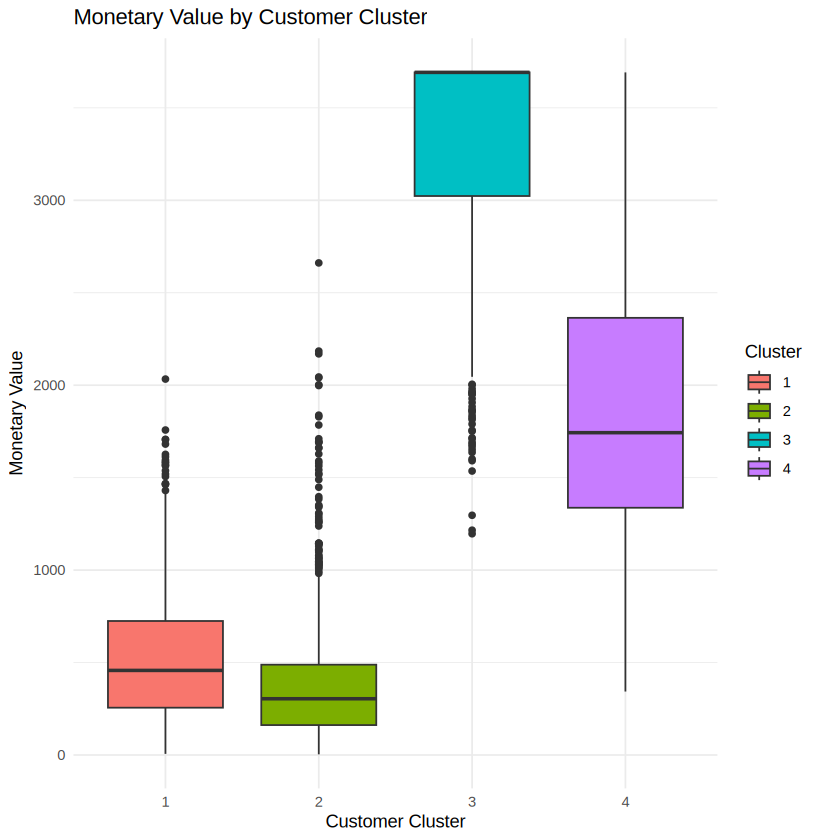

In [110]:
ggplot(
  customer_data_clean,
  aes(
    x = Cluster,
    y = Monetary,
    fill = Cluster
  )
) +
  geom_boxplot() +
  labs(
    title = "Monetary Value by Customer Cluster",
    x = "Customer Cluster",
    y = "Monetary Value"
  ) +
  theme_minimal()

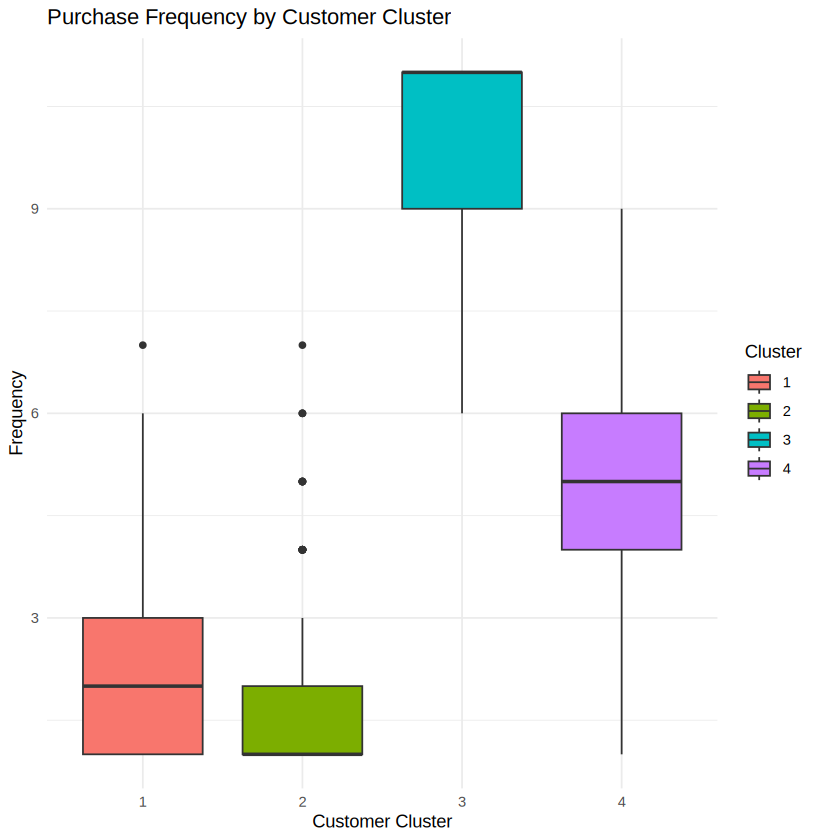

In [111]:
ggplot(
  customer_data_clean,
  aes(
    x = Cluster,
    y = Frequency,
    fill = Cluster
  )
) +
  geom_boxplot() +
  labs(
    title = "Purchase Frequency by Customer Cluster",
    x = "Customer Cluster",
    y = "Frequency"
  ) +
  theme_minimal()

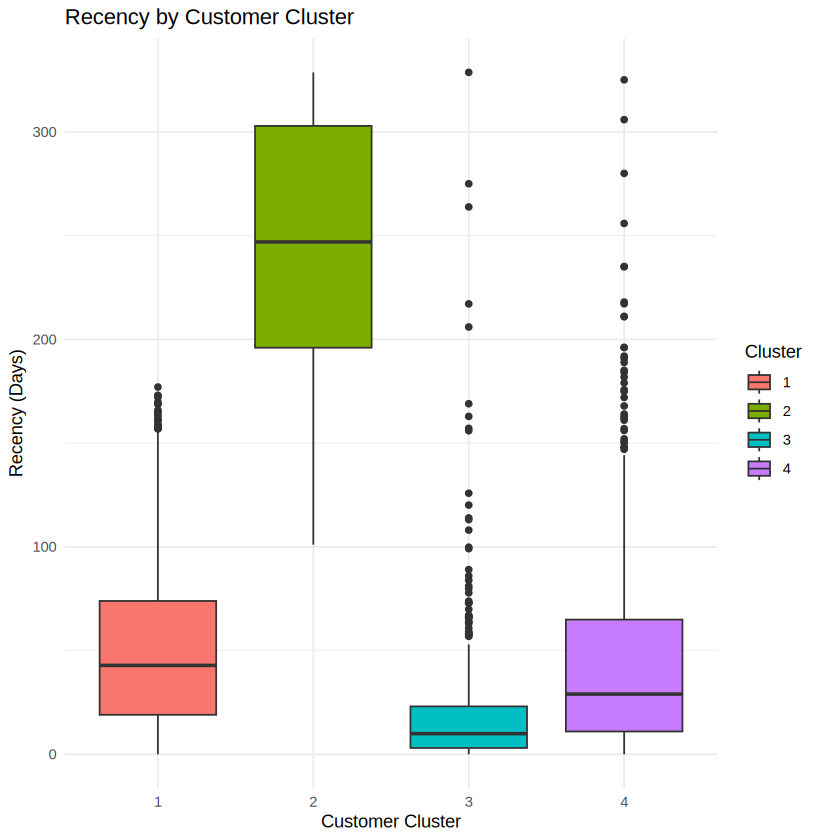

In [112]:
ggplot(
  customer_data_clean,
  aes(
    x = Cluster,
    y = Recency,
    fill = Cluster
  )
) +
  geom_boxplot() +
  labs(
    title = "Recency by Customer Cluster",
    x = "Customer Cluster",
    y = "Recency (Days)"
  ) +
  theme_minimal()

In [113]:
cluster_profile_scaled <- customer_data_clean %>%
  group_by(Cluster) %>%
  summarise(
    Recency = mean(Recency),
    Frequency = mean(Frequency),
    Monetary = mean(Monetary),
    TotalQuantity = mean(TotalQuantity),
    AvgTransactionValue = mean(AvgTransactionValue),
    .groups = "drop"
  )

cluster_profile_scaled

Cluster,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,51.09712,2.026501,522.9942,312.2217,16.62834
2,246.25434,1.408143,392.0864,207.6334,21.26150
3,19.99953,9.815385,3321.1382,1950.4000,23.84930
4,45.28154,4.702341,1920.9314,1150.1148,23.43281


In [114]:
profile_matrix <- cluster_profile_scaled %>%
  select(
    Recency,
    Frequency,
    Monetary,
    TotalQuantity,
    AvgTransactionValue
  )

profile_scaled <- scale(profile_matrix)

profile_scaled <- data.frame(
  Cluster = cluster_profile_scaled$Cluster,
  profile_scaled
)

profile_scaled

Cluster,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.3781925,-0.64297065,-0.7392729,-0.7278190,-1.409147249
2,1.4874573,-0.80448645,-0.8344980,-0.8562135,-0.009513174
3,-0.6754770,1.39149507,1.2961552,1.2832385,0.772238215
4,-0.4337879,0.05596203,0.2776156,0.3007939,0.646422207


In [115]:
cluster_profile_scaled

Cluster,Recency,Frequency,Monetary,TotalQuantity,AvgTransactionValue
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,51.09712,2.026501,522.9942,312.2217,16.62834
2,246.25434,1.408143,392.0864,207.6334,21.26150
3,19.99953,9.815385,3321.1382,1950.4000,23.84930
4,45.28154,4.702341,1920.9314,1150.1148,23.43281


In [116]:
cluster_summary <- customer_data_clean %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    Avg_Recency = round(mean(Recency), 2),
    Avg_Frequency = round(mean(Frequency), 2),
    Avg_Monetary = round(mean(Monetary), 2),
    Avg_Quantity = round(mean(TotalQuantity), 2),
    Avg_Transaction_Value =
      round(mean(AvgTransactionValue), 2),
    .groups = "drop"
  )

cluster_summary

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1849,51.10,2.03,522.99,312.22,16.63
2,1007,246.25,1.41,392.09,207.63,21.26
3,585,20.00,9.82,3321.14,1950.40,23.85
4,897,45.28,4.70,1920.93,1150.11,23.43


In [117]:
high_value_cluster

[1] 3
Levels: 1 2 3 4

In [118]:
high_value_profile <- cluster_summary %>%
  filter(
    Cluster == high_value_cluster
  )

high_value_profile

Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Quantity,Avg_Transaction_Value
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,585,20,9.82,3321.14,1950.4,23.85


In [119]:
high_value_percentage <- (
  sum(customer_data_clean$HighValue == "Yes") /
  nrow(customer_data_clean)
) * 100

round(high_value_percentage, 2)

[1] 13.49

In [120]:
model_comparison_long <- model_comparison %>%
  pivot_longer(
    cols = c(
      Accuracy,
      Precision,
      Recall,
      F1_Score,
      ROC_AUC
    ),
    names_to = "Metric",
    values_to = "Score"
  )

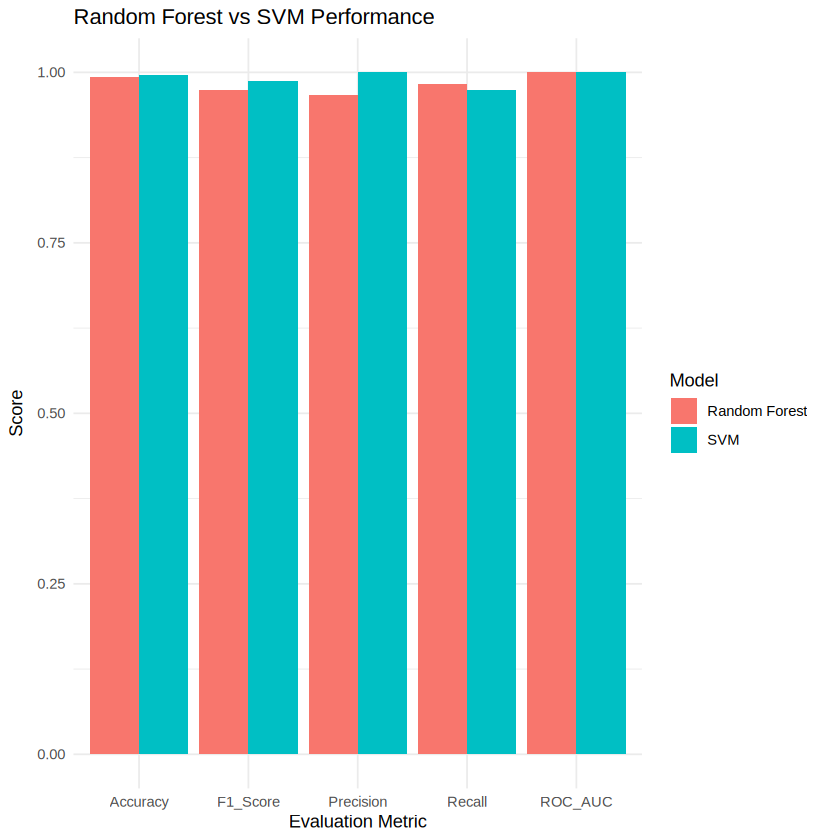

In [121]:
ggplot(
  model_comparison_long,
  aes(
    x = Metric,
    y = Score,
    fill = Model
  )
) +
  geom_col(
    position = "dodge"
  ) +
  ylim(0, 1) +
  labs(
    title = "Random Forest vs SVM Performance",
    x = "Evaluation Metric",
    y = "Score"
  ) +
  theme_minimal()

In [122]:
cat("========================================\n")
cat("CUSTOMER SEGMENTATION RESULTS\n")
cat("========================================\n\n")

cat("Number of customers:",
    nrow(customer_data_clean), "\n\n")

cat("Number of clusters:",
    optimal_k, "\n\n")

cat("Average Silhouette Score:",
    round(avg_silhouette, 4), "\n\n")

cat("High-value cluster:",
    as.character(high_value_cluster), "\n\n")

cat("High-value customers (%):",
    round(high_value_percentage, 2), "%\n\n")

cat("========================================\n")
cat("MODEL COMPARISON\n")
cat("========================================\n")

print(model_comparison)

cat("\n========================================\n")
cat("CLUSTER PROFILE\n")
cat("========================================\n")

print(cluster_summary)

CUSTOMER SEGMENTATION RESULTS

Number of customers: 4338 

Number of clusters: 4 

Average Silhouette Score: 0.3289 

High-value cluster: 3 

High-value customers (%): 13.49 %

MODEL COMPARISON
          Model  Accuracy Precision   Recall  F1_Score   ROC_AUC
1 Random Forest 0.9930796 0.9663866 0.982906 0.9745763 0.9998063
2           SVM 0.9965398 1.0000000 0.974359 0.9870130 0.9999772

CLUSTER PROFILE
# A tibble: 4 × 7
  Cluster Customers Avg_Recency Avg_Frequency Avg_Monetary Avg_Quantity
  <fct>       <int>       <dbl>         <dbl>        <dbl>        <dbl>
1 1            1849        51.1          2.03         523.         312.
2 2            1007       246.           1.41         392.         208.
3 3             585        20            9.82        3321.        1950.
4 4             897        45.3          4.7         1921.        1150.
# ℹ 1 more variable: Avg_Transaction_Value <dbl>
